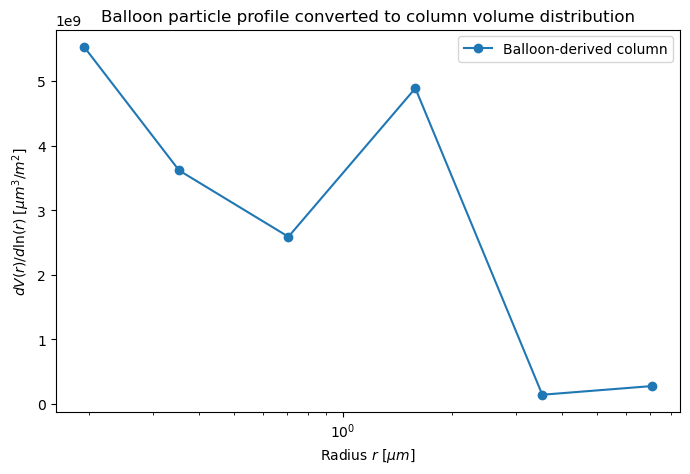

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------------
# 1. Load balloon particle counter data
# --------------------------------------------------
balloon = pd.read_csv("Particle Counter Balloon.csv")

# Parse time
balloon["Time_dt"] = pd.to_datetime(balloon["Time"], errors="coerce")

# Keep the columns we need
count_cols = [
    "Count1 (dM3)", "Count2 (dM3)", "Count3 (dM3)",
    "Count4 (dM3)", "Count5 (dM3)", "Count6 (dM3)"
]
size_cols = ["Size1", "Size2", "Size3", "Size4", "Size5", "Size6"]

# Convert to numeric
for col in count_cols + size_cols + ["altitude"]:
    balloon[col] = pd.to_numeric(balloon[col], errors="coerce")

# Sort by time
balloon = balloon.sort_values("Time_dt").reset_index(drop=True)

# --------------------------------------------------
# 2. Interpolate altitude to all rows
# --------------------------------------------------
# altitude is missing in many rows, so interpolate by time index
balloon["altitude_interp"] = balloon["altitude"].interpolate(method="linear")

# Drop rows that still do not have valid time or altitude
balloon = balloon.dropna(subset=["Time_dt", "altitude_interp"])

# --------------------------------------------------
# 3. Define particle bin edges and bin-center radii
# --------------------------------------------------
# GT-521S channel thresholds in microns from the file
# 0.3, 0.5, 1.0, 2.0, 5.0, 10.0 µm
#
# We treat the differential bins approximately as:
# [0.3,0.5], [0.5,1.0], [1.0,2.0], [2.0,5.0], [5.0,10.0]
#
# Count6 is tricky because 10 µm is the top threshold.
# If your Count6 is differential, you need an upper edge assumption.
# A simple first approximation is [10, 20] µm, but this should be stated clearly.
#
# If instead Count6 is cumulative or not useful, you may exclude it.

bin_edges = np.array([0.3, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0])  # microns
r_mid = np.sqrt(bin_edges[:-1] * bin_edges[1:]) / 2.0        # bin-center radius in microns
# Note:
# geometric mean diameter = sqrt(d1*d2)
# radius = diameter / 2

dlnr = np.log((bin_edges[1:] / 2.0) / (bin_edges[:-1] / 2.0))
# same as ln(d2/d1), since factor 1/2 cancels

# --------------------------------------------------
# 4. Map count columns to bins
# --------------------------------------------------
# Assuming Count1..Count6 correspond to differential bins.
# If your data structure differs, adjust here.
bin_count_cols = count_cols

# --------------------------------------------------
# 5. Convert number concentration to volume concentration
# --------------------------------------------------
# Counts are in particles / m^3 from dM3
# Volume per particle in microns^3:
# Vp = 4/3 * pi * r^3
#
# Then volume concentration:
# dV_bin(z) = n_bin(z) * Vp_bin
#
# Units become microns^3 / m^3

for i, col in enumerate(bin_count_cols):
    vp = (4.0 / 3.0) * np.pi * (r_mid[i] ** 3)   # micron^3 per particle
    balloon[f"Vconc_bin{i+1}"] = balloon[col] * vp

# --------------------------------------------------
# 6. Integrate over altitude using trapezoidal rule
# --------------------------------------------------
# altitude appears to be in meters in your CSV.
# We sort by altitude and integrate each bin vertically.

prof = balloon.sort_values("altitude_interp").copy()

z = prof["altitude_interp"].values  # meters

column_volume = []
for i in range(6):
    y = prof[f"Vconc_bin{i+1}"].values
    col_int = np.trapz(y, z)   # micron^3 / m^2
    column_volume.append(col_int)

column_volume = np.array(column_volume)

# --------------------------------------------------
# 7. Convert to dV/dln(r)
# --------------------------------------------------
# Approximate AERONET-style distribution
dvdlnr = column_volume / dlnr   # micron^3 / m^2

# --------------------------------------------------
# 8. Plot balloon-derived column size distribution
# --------------------------------------------------
plt.figure(figsize=(7,5))
plt.plot(r_mid, dvdlnr, "o-", label="Balloon-derived column")
plt.xscale("log")
plt.xlabel(r"Radius $r$ [$\mu m$]")
plt.ylabel(r"$dV(r)/d\ln(r)$ [$\mu m^3 / m^2$]")
plt.title("Balloon particle profile converted to column volume distribution")
plt.legend()
plt.tight_layout()
plt.show()

Balloon threshold diameters [um]: [ 0.3  0.5  1.   2.   5.  10. ]
Including open-ended last bin:
Assumed last upper radius edge [um]: 15.0
Assumed last upper diameter edge [um]: 30.0
Overlap-only scale factor: 0.7995065099947208
Shape-normalization factor applied to rebinned balloon curve: 1.512408262389983


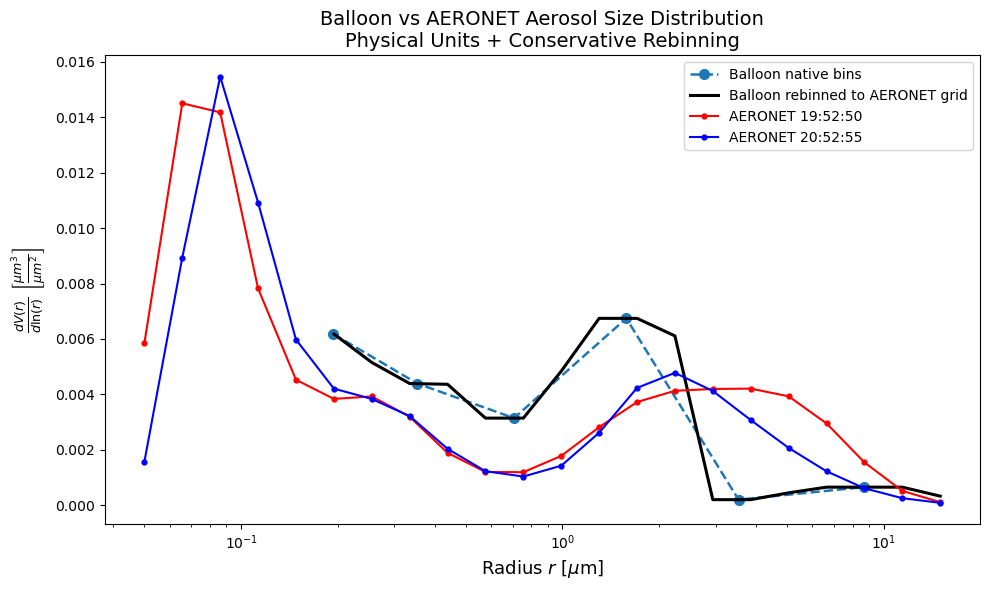

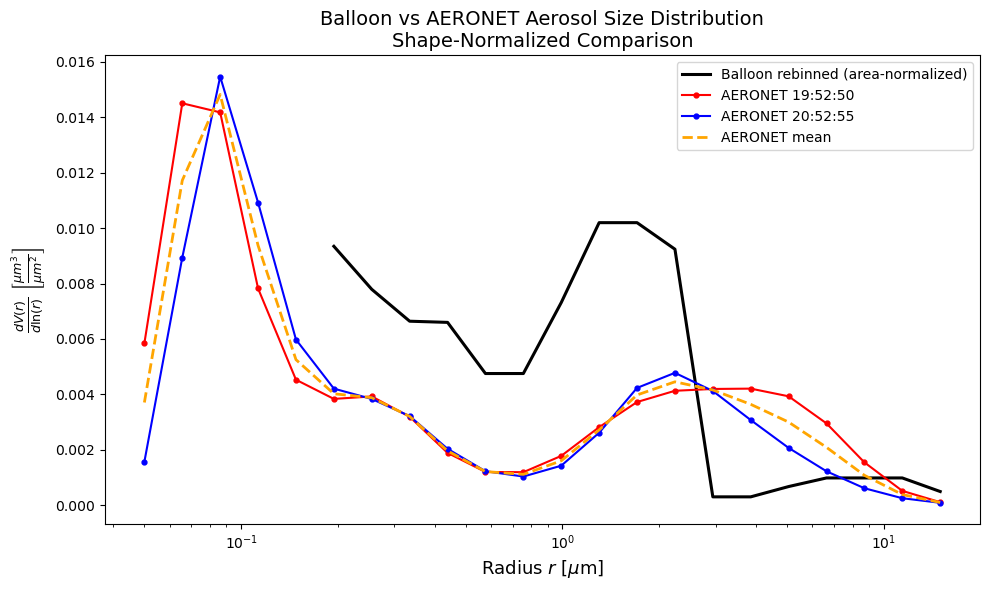


Native balloon bins:
 r_left_um  r_right_um  r_center_um  balloon_dVdlnr_native_um3_per_um2
      0.15        0.25     0.193649                           0.006179
      0.25        0.50     0.353553                           0.004391
      0.50        1.00     0.707107                           0.003141
      1.00        2.50     1.581139                           0.006743
      2.50        5.00     3.535534                           0.000197
      5.00       15.00     8.660254                           0.000649

Rebinned comparison table:
 aeronet_radius_um  balloon_rebinned_dVdlnr_um3_per_um2  balloon_rebinned_norm_um3_per_um2  aeronet_1  aeronet_2  aeronet_mean
          0.050000                             0.000000                           0.000000   0.005845   0.001566      0.003706
          0.065604                             0.000000                           0.000000   0.014509   0.008939      0.011724
          0.086077                             0.000000                 

In [2]:
import numpy as np
import pandas as pd
from scipy.integrate import simpson
import matplotlib.pyplot as plt

# ============================================================
# USER SETTINGS
# ============================================================
BALLOON_FILE = "Particle Counter Balloon.csv"
AERONET_FILE = "20260207_Rexburg_Idaho (1).csv"

# If True, include the open-ended last balloon bin (>10 um diameter)
# by assigning it an upper diameter edge equal to 2 * max(AERONET radius).
# If False, the last balloon bin is excluded because it is open-ended.
INCLUDE_OPEN_ENDED_LAST_BIN = True

# Altitude interpolation settings
USE_INTERPOLATED_ALTITUDE = True

# For shape-only comparison, normalize balloon curve to the mean AERONET area
MAKE_SHAPE_NORMALIZED_PLOT = True

# ============================================================
# HELPER FUNCTIONS
# ============================================================
def geometric_bin_edges_from_centers(centers):
    """
    Build log-spaced edges from bin centers.
    centers must be positive and sorted.
    """
    centers = np.asarray(centers, dtype=float)
    logc = np.log(centers)

    edges = np.empty(len(centers) + 1, dtype=float)
    edges[1:-1] = np.exp(0.5 * (logc[:-1] + logc[1:]))

    # extrapolate first/last edge in log-space
    edges[0] = np.exp(logc[0] - 0.5 * (logc[1] - logc[0]))
    edges[-1] = np.exp(logc[-1] + 0.5 * (logc[-1] - logc[-2]))
    return edges


def rebin_dvdlnr_conserving_volume(src_edges, src_dvdlnr, dst_edges):
    """
    Rebin piecewise-constant dV/dlnr from src bins to dst bins
    while conserving total integrated volume in ln(r) space.

    Inputs:
        src_edges : source bin edges in radius units
        src_dvdlnr: source dV/dlnr values on source bins
        dst_edges : destination bin edges in radius units

    Returns:
        dst_dvdlnr on destination bins
    """
    src_edges = np.asarray(src_edges, dtype=float)
    src_dvdlnr = np.asarray(src_dvdlnr, dtype=float)
    dst_edges = np.asarray(dst_edges, dtype=float)

    src_ln_edges = np.log(src_edges)
    dst_ln_edges = np.log(dst_edges)

    dst_volume = np.zeros(len(dst_edges) - 1, dtype=float)

    for i in range(len(src_dvdlnr)):
        s1 = src_ln_edges[i]
        s2 = src_ln_edges[i + 1]
        src_val = src_dvdlnr[i]

        for j in range(len(dst_volume)):
            d1 = dst_ln_edges[j]
            d2 = dst_ln_edges[j + 1]

            overlap = max(0.0, min(s2, d2) - max(s1, d1))
            if overlap > 0:
                dst_volume[j] += src_val * overlap

    dst_dlnr = np.diff(dst_ln_edges)
    dst_dvdlnr = dst_volume / dst_dlnr
    return dst_dvdlnr

def integrate_profile_over_altitude(z, y):

    z = np.asarray(z, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = np.isfinite(z) & np.isfinite(y)
    z = z[mask]
    y = y[mask]

    if len(z) < 2:
        return np.nan

    order = np.argsort(z)
    z = z[order]
    y = y[order]

    # combine duplicate altitude values
    df = pd.DataFrame({"z": z, "y": y}).groupby("z", as_index=False).mean()

    z = df["z"].values
    y = df["y"].values

    return simpson(y, x=z)


def normalize_to_reference_area(x, y, xref, yref):
    """
    Scale y so that its integrated area over common x-range in ln(r)
    matches the reference area.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    xref = np.asarray(xref, dtype=float)
    yref = np.asarray(yref, dtype=float)

    xmin = max(np.min(x), np.min(xref))
    xmax = min(np.max(x), np.max(xref))

    mask1 = (x >= xmin) & (x <= xmax)
    mask2 = (xref >= xmin) & (xref <= xmax)

    if np.sum(mask1) < 2 or np.sum(mask2) < 2:
        return y, 1.0

    area_y = np.trapz(y[mask1], np.log(x[mask1]))
    area_ref = np.trapz(yref[mask2], np.log(xref[mask2]))

    if area_y == 0 or not np.isfinite(area_y):
        return y, 1.0

    scale = area_ref / area_y
    return y * scale, scale


# ============================================================
# 1. LOAD BALLOON DATA
# ============================================================
balloon = pd.read_csv(BALLOON_FILE)

count_cols = [
    "Count1 (dM3)", "Count2 (dM3)", "Count3 (dM3)",
    "Count4 (dM3)", "Count5 (dM3)", "Count6 (dM3)"
]

size_cols = ["Size1", "Size2", "Size3", "Size4", "Size5", "Size6"]

# Convert numeric columns
for col in count_cols + size_cols + ["altitude"]:
    if col in balloon.columns:
        balloon[col] = pd.to_numeric(balloon[col], errors="coerce")

# Parse time if available
if "Time" in balloon.columns:
    balloon["Time_dt"] = pd.to_datetime(balloon["Time"], errors="coerce")

# Interpolate altitude if desired
if USE_INTERPOLATED_ALTITUDE:
    if "Time_dt" in balloon.columns and balloon["Time_dt"].notna().sum() > 1:
        balloon = balloon.sort_values("Time_dt").reset_index(drop=True)
        balloon["altitude_used"] = balloon["altitude"].interpolate(method="linear", limit_direction="both")
    else:
        balloon["altitude_used"] = balloon["altitude"].interpolate(method="linear", limit_direction="both")
else:
    balloon["altitude_used"] = balloon["altitude"]

# Keep rows with altitude and at least one count
balloon = balloon.dropna(subset=["altitude_used"]).copy()

# ============================================================
# 2. DEFINE BALLOON BINS
# ============================================================
# Threshold diameters in microns from the balloon CSV
threshold_diam = balloon.loc[balloon.index[0], size_cols].astype(float).values

# Example from your file:
# [0.3, 0.5, 1.0, 2.0, 5.0, 10.0]  (diameter in um)
print("Balloon threshold diameters [um]:", threshold_diam)

# Convert threshold diameters -> radius thresholds for closed bins
# Closed differential bins:
# [0.3,0.5], [0.5,1.0], [1.0,2.0], [2.0,5.0], [5.0,10.0]
closed_diam_edges = threshold_diam.copy()
closed_radius_edges = closed_diam_edges / 2.0  # radius in um

# The 5 closed bins use Count1..Count5 if we exclude the open-ended last bin.
# If we include Count6, we need to assume an upper radius edge later.
balloon_count_cols = count_cols[:5]
balloon_radius_edges = closed_radius_edges

# ============================================================
# 3. LOAD AERONET DATA
# ============================================================
aeronet = pd.read_csv(AERONET_FILE)

# Radius columns are columns 5:27 in your file
aero_radius = aeronet.columns[5:27].astype(float).values  # radius in um
aero_y1 = aeronet.iloc[0, 5:27].astype(float).values
aero_y2 = aeronet.iloc[1, 5:27].astype(float).values

# AERONET edges inferred from the radius grid
aero_edges = geometric_bin_edges_from_centers(aero_radius)

# If including the open-ended GT-521S last bin, assign it an upper diameter edge
# based on the max AERONET radius.
if INCLUDE_OPEN_ENDED_LAST_BIN:
    max_aero_radius = np.max(aero_radius)
    assumed_last_upper_radius = max_aero_radius
    assumed_last_upper_diameter = 2.0 * assumed_last_upper_radius

    balloon_count_cols = count_cols[:6]
    balloon_radius_edges = np.concatenate([closed_radius_edges, [assumed_last_upper_radius]])

    print("Including open-ended last bin:")
    print("Assumed last upper radius edge [um]:", assumed_last_upper_radius)
    print("Assumed last upper diameter edge [um]:", assumed_last_upper_diameter)
else:
    print("Excluding open-ended last bin (>10 um diameter) from comparison.")

# ============================================================
# 4. BUILD BALLOON COLUMN SIZE DISTRIBUTION
# ============================================================
# We will treat the balloon dM3 channels as number concentration [particles/m^3]
# in each differential bin, convert to volume concentration, then integrate over altitude.
#
# Result:
#   column volume per bin [um^3 / m^2]
# Then divide by 1e12 to get:
#   [um^3 / um^2]
# Then divide by dlnr to get:
#   dV/dlnr [um^3 / um^2]

z = balloon["altitude_used"].values

balloon_native_dvdlnr = []
balloon_native_centers = []
balloon_native_bin_volume = []

for i, col in enumerate(balloon_count_cols):
    r1 = balloon_radius_edges[i]
    r2 = balloon_radius_edges[i + 1]

    # geometric center radius
    rc = np.sqrt(r1 * r2)
    balloon_native_centers.append(rc)

    # bin width in ln(r)
    dlnr = np.log(r2 / r1)

    # log-space bin-mean particle volume for dV/dlnr work
    # average of r^3 over ln(r) inside the bin
    mean_r3 = (r2**3 - r1**3) / (3.0 * np.log(r2 / r1))
    particle_volume_um3 = (4.0 / 3.0) * np.pi * mean_r3

    # number concentration profile [particles/m^3]
    n_profile = balloon[col].values

    # volume concentration profile [um^3 / m^3]
    v_profile = n_profile * particle_volume_um3

    # integrate vertically -> [um^3 / m^2]
    col_volume_um3_per_m2 = integrate_profile_over_altitude(z, v_profile)

    # convert m^2 -> um^2
    col_volume_um3_per_um2 = col_volume_um3_per_m2 / 1e12

    # native dV/dlnr
    dvdlnr_val = col_volume_um3_per_um2 / dlnr

    balloon_native_bin_volume.append(col_volume_um3_per_um2)
    balloon_native_dvdlnr.append(dvdlnr_val)

balloon_native_centers = np.array(balloon_native_centers)
balloon_native_dvdlnr = np.array(balloon_native_dvdlnr)
balloon_native_bin_volume = np.array(balloon_native_bin_volume)

# Native balloon bin edges already in radius units
balloon_native_edges = balloon_radius_edges.copy()

# ============================================================
# 5. REBIN BALLOON ONTO AERONET GRID
# ============================================================
balloon_rebinned_dvdlnr = rebin_dvdlnr_conserving_volume(
    src_edges=balloon_native_edges,
    src_dvdlnr=balloon_native_dvdlnr,
    dst_edges=aero_edges
)

# ============================================================
# 6. BUILD A REFERENCE AERONET CURVE
# ============================================================
# Use the mean of the two AERONET rows as a comparison reference
aero_mean = 0.5 * (aero_y1 + aero_y2)

# overlap region only
rmin_overlap = balloon_native_edges[0]
rmax_overlap = balloon_native_edges[-1]

overlap_mask = (aero_radius >= rmin_overlap) & (aero_radius <= rmax_overlap)

balloon_overlap = balloon_rebinned_dvdlnr[overlap_mask]
aero_overlap = aero_mean[overlap_mask]
r_overlap = aero_radius[overlap_mask]

# integrated areas in ln(r)
balloon_area = np.trapz(balloon_overlap, np.log(r_overlap))
aero_area = np.trapz(aero_overlap, np.log(r_overlap))

overlap_scale = aero_area / balloon_area
balloon_rebinned_overlap_scaled = balloon_rebinned_dvdlnr * overlap_scale

print("Overlap-only scale factor:", overlap_scale)

# Shape-normalized balloon curve
balloon_rebinned_norm, norm_factor = normalize_to_reference_area(
    aero_radius, balloon_rebinned_dvdlnr,
    aero_radius, aero_mean
)

print("Shape-normalization factor applied to rebinned balloon curve:", norm_factor)

# ------------------------------------------------------------
# Mask balloon rebinned curves outside the balloon radius range
# ------------------------------------------------------------
rmin_balloon = balloon_native_edges[0]
rmax_balloon = balloon_native_edges[-1]

valid_mask = (aero_radius >= rmin_balloon) & (aero_radius <= rmax_balloon)

balloon_rebinned_plot = np.full_like(balloon_rebinned_dvdlnr, np.nan, dtype=float)
balloon_rebinned_plot[valid_mask] = balloon_rebinned_dvdlnr[valid_mask]

balloon_rebinned_norm_plot = np.full_like(balloon_rebinned_norm, np.nan, dtype=float)
balloon_rebinned_norm_plot[valid_mask] = balloon_rebinned_norm[valid_mask]

# ============================================================
# 7. PLOT: PHYSICAL COMPARISON
# ============================================================
plt.figure(figsize=(10, 6))

plt.plot(
    balloon_native_centers,
    balloon_native_dvdlnr,
    "o--",
    linewidth=1.8,
    markersize=7,
    label="Balloon native bins"
)

plt.plot(
    aero_radius,
    balloon_rebinned_plot,
    "k-",
    linewidth=2.2,
    label="Balloon rebinned to AERONET grid"
)

plt.plot(
    aero_radius,
    aero_y1,
    "r.-",
    linewidth=1.5,
    markersize=7,
    label="AERONET 19:52:50"
)

plt.plot(
    aero_radius,
    aero_y2,
    "b.-",
    linewidth=1.5,
    markersize=7,
    label="AERONET 20:52:55"
)

plt.xscale("log")
# plt.yscale("log")
plt.xlabel(r"Radius $r$ [$\mu$m]", fontsize=13)
plt.ylabel(r"$\frac{dV(r)}{d\ln(r)}\ \left[\frac{\mu m^3}{\mu m^2}\right]$", fontsize=13)
plt.title("Balloon vs AERONET Aerosol Size Distribution\nPhysical Units + Conservative Rebinning", fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# 8. PLOT: SHAPE-NORMALIZED COMPARISON
# ============================================================
if MAKE_SHAPE_NORMALIZED_PLOT:
    plt.figure(figsize=(10, 6))

    plt.plot(
    aero_radius,
    balloon_rebinned_norm_plot,
    "k-",
    linewidth=2.2,
    label="Balloon rebinned (area-normalized)"
)

    plt.plot(
        aero_radius,
        aero_y1,
        "r.-",
        linewidth=1.5,
        markersize=7,
        label="AERONET 19:52:50"
    )

    plt.plot(
        aero_radius,
        aero_y2,
        "b.-",
        linewidth=1.5,
        markersize=7,
        label="AERONET 20:52:55"
    )

    plt.plot(
        aero_radius,
        aero_mean,
        color="orange",
        linestyle="--",
        linewidth=2,
        label="AERONET mean"
    )

    plt.xscale("log")
    # plt.yscale("log")
    plt.xlabel(r"Radius $r$ [$\mu$m]", fontsize=13)
    plt.ylabel(r"$\frac{dV(r)}{d\ln(r)}\ \left[\frac{\mu m^3}{\mu m^2}\right]$", fontsize=13)
    plt.title("Balloon vs AERONET Aerosol Size Distribution\nShape-Normalized Comparison", fontsize=14)
    plt.legend()
    plt.tight_layout()
    plt.show()

# ============================================================
# 9. OPTIONAL: PRINT TABLES FOR CHECKING
# ============================================================
native_table = pd.DataFrame({
    "r_left_um": balloon_native_edges[:-1],
    "r_right_um": balloon_native_edges[1:],
    "r_center_um": balloon_native_centers,
    "balloon_dVdlnr_native_um3_per_um2": balloon_native_dvdlnr
})

rebinned_table = pd.DataFrame({
    "aeronet_radius_um": aero_radius,
    "balloon_rebinned_dVdlnr_um3_per_um2": balloon_rebinned_dvdlnr,
    "balloon_rebinned_norm_um3_per_um2": balloon_rebinned_norm,
    "aeronet_1": aero_y1,
    "aeronet_2": aero_y2,
    "aeronet_mean": aero_mean
})

print("\nNative balloon bins:")
print(native_table.to_string(index=False))

print("\nRebinned comparison table:")
print(rebinned_table.to_string(index=False))